In [1]:
import json
import logging
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

In [2]:
# ── Paths ──────────────────────────────────────────────────────────
DATA_PATH = Path("../data/training/training_dataset.parquet")   # notebook is inside notebooks/, so ../
FIGURES_DIR = Path("../reports/eda/figures")
STATS_PATH = Path("../reports/eda/eda_stats.json")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
STATS_PATH.parent.mkdir(parents=True, exist_ok=True)

# ── Column Groups ──────────────────────────────────────────────────
POLLUTANT_COLS = ["pm25", "pm10", "no2", "so2", "co", "o3"]
WEATHER_COLS   = ["temperature", "feels_like", "humidity", "pressure", "visibility", "wind_speed", "cloudiness"]
TARGET_COL     = "aqi"
TIME_COL       = "timestamp"
CITY_COL       = "city"

# ── Stats Collector ──────────────────────────────────────────────
all_stats = {}   # collects stats from every section, saved as JSON at the end

In [3]:
df = pd.read_parquet(DATA_PATH)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], utc=True, errors="coerce")

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 105054 rows, 31 columns


,city,country,latitude,longitude,timestamp,temperature,feels_like,humidity,pressure,visibility,...,o3,source,created_at,hour,day,month,day_of_week,is_weekend,aqi_change_rate,aqi_rolling_mean_3h
0,Islamabad,PK,33.6844,73.0479,2022-07-21 00:00:00+00:00,26.6,30.6,83,942,-1,...,79.07641,"Open-Meteo (historical, CAMS reanalysis)",2026-07-21T11:56:30.908001+00:00,0.0,21.0,7.0,3.0,0.0,0.0,0.0
1,Islamabad,PK,33.6844,73.0479,2022-07-21 01:00:00+00:00,26.4,30.6,84,940,-1,...,79.07641,"Open-Meteo (historical, CAMS reanalysis)",2026-07-21T11:56:30.908001+00:00,1.0,21.0,7.0,3.0,0.0,0.0,0.0
2,Islamabad,PK,33.6844,73.0479,2022-07-21 02:00:00+00:00,26.1,30.3,84,940,-1,...,79.07641,"Open-Meteo (historical, CAMS reanalysis)",2026-07-21T11:56:30.908001+00:00,2.0,21.0,7.0,3.0,0.0,0.0,0.0
3,Islamabad,PK,33.6844,73.0479,2022-07-21 03:00:00+00:00,25.8,30.2,87,941,-1,...,79.07641,"Open-Meteo (historical, CAMS reanalysis)",2026-07-21T11:56:30.908001+00:00,3.0,21.0,7.0,3.0,0.0,0.0,0.0
4,Islamabad,PK,33.6844,73.0479,2022-07-21 04:00:00+00:00,25.6,30.0,88,941,-1,...,79.07641,"Open-Meteo (historical, CAMS reanalysis)",2026-07-21T11:56:30.908001+00:00,4.0,21.0,7.0,3.0,0.0,0.0,0.0


In [4]:
# ── Dataset Summary for JSON ─────────────────────────────────────
dataset_summary = {
    "shape": {"rows": df.shape[0], "columns": df.shape[1]},
    "memory_mb": round(df.memory_usage(deep=True).sum() / 1024**2, 2),
    "dtypes": {col: str(dtype) for col, dtype in df.dtypes.items()},
    "columns": list(df.columns),
}
all_stats["dataset_summary"] = dataset_summary

# ── Display ──────────────────────────────────────────────────────
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105054 entries, 0 to 105053
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype              
---  ------               --------------   -----              
 0   city                 105054 non-null  object             
 1   country              105054 non-null  object             
 2   latitude             105054 non-null  float64            
 3   longitude            105054 non-null  float64            
 4   timestamp            105054 non-null  datetime64[ns, UTC]
 5   temperature          105054 non-null  float64            
 6   feels_like           105054 non-null  float64            
 7   humidity             105054 non-null  int64              
 8   pressure             105054 non-null  int64              
 9   visibility           105054 non-null  int64              
 10  wind_speed           105054 non-null  float64            
 11  wind_degree          105054 non-null  int64              
 12  cl

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
city,105054,3,Islamabad,35018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,105054,1,PK,105054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,105054.0,NaN,NaN,NaN,30.031601,24.8607,24.8607,31.5497,33.6844,33.7104,3.758819
longitude,105054.0,NaN,NaN,NaN,71.464203,67.0011,67.0011,73.0479,74.3436,74.3436,3.199926
timestamp,105054,NaN,NaN,NaN,2024-07-19 12:29:58.645192192+00:00,2022-07-21 00:00:00+00:00,2023-07-20 18:00:00+00:00,2024-07-19 12:30:00+00:00,2025-07-19 07:00:00+00:00,2026-07-18 23:00:00+00:00,NaN
temperature,105054.0,NaN,NaN,NaN,23.924174,1.1,18.6,25.5,29.3,46.5,7.570892
feels_like,105054.0,NaN,NaN,NaN,25.183866,-2.6,17.7,27.2,32.9,47.6,9.645793
humidity,105054.0,NaN,NaN,NaN,63.557218,5.0,48.0,66.0,81.0,100.0,21.486077
pressure,105054.0,NaN,NaN,NaN,980.128896,934.0,954.0,983.0,1002.0,1024.0,24.508805
visibility,105054.0,NaN,NaN,NaN,-0.428808,-1.0,-1.0,-1.0,-1.0,10000.0,75.579223


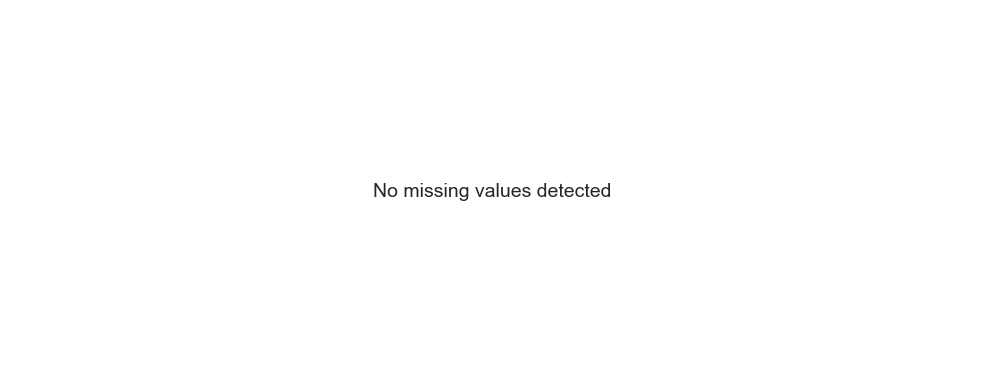

{}

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_stats = {
    col: {"missing_count": int(missing[col]), "missing_pct": float(missing_pct[col])}
    for col in df.columns
    if missing[col] > 0
}
all_stats["missing_values"] = missing_stats
all_stats["total_missing_pct"] = round(float(missing.sum() / (df.shape[0] * df.shape[1]) * 100), 4)

fig, ax = plt.subplots(figsize=(10, max(4, len(missing_stats) * 0.35)))
if missing_stats:
    cols = list(missing_stats.keys())
    pct = [missing_stats[c]["missing_pct"] for c in cols]
    ax.barh(cols, pct, color="#d1495b")
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Value Percentage by Column")
else:
    ax.text(0.5, 0.5, "No missing values detected", ha="center", va="center", fontsize=14)
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "missing_values.png", dpi=110, bbox_inches="tight")
plt.show()

missing_stats

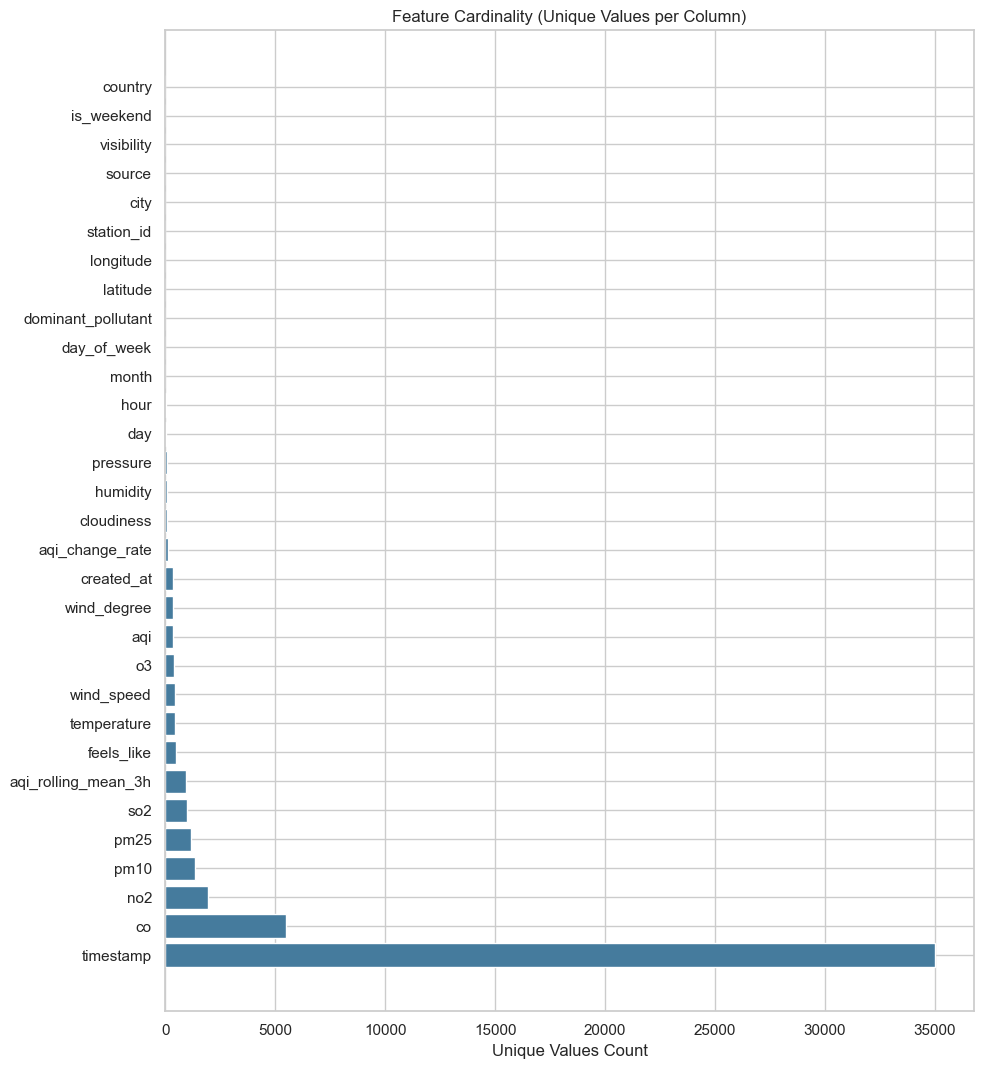

timestamp              35022
co                      5510
no2                     1941
pm10                    1347
pm25                    1154
so2                     1006
aqi_rolling_mean_3h      941
feels_like               490
temperature              447
wind_speed               426
o3                       403
aqi                      365
wind_degree              360
created_at               356
aqi_change_rate          110
cloudiness               101
humidity                  96
pressure                  91
day                       31
hour                      24
month                     12
day_of_week                7
dominant_pollutant         7
latitude                   5
longitude                  5
station_id                 4
city                       3
source                     2
visibility                 2
is_weekend                 2
country                    1
dtype: int64

In [6]:
# Cardinality = number of unique values per column
cardinality = df.nunique().sort_values(ascending=False)
cardinality_pct = (cardinality / len(df) * 100).round(2)

all_stats["feature_cardinality"] = {
    col: {"unique": int(cardinality[col]), "unique_pct": float(cardinality_pct[col])}
    for col in cardinality.index
}

fig, ax = plt.subplots(figsize=(10, max(4, len(cardinality) * 0.35)))
ax.barh(cardinality.index, cardinality.values, color="#457b9d")
ax.set_xlabel("Unique Values Count")
ax.set_title("Feature Cardinality (Unique Values per Column)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_cardinality.png", dpi=110, bbox_inches="tight")
plt.show()

cardinality

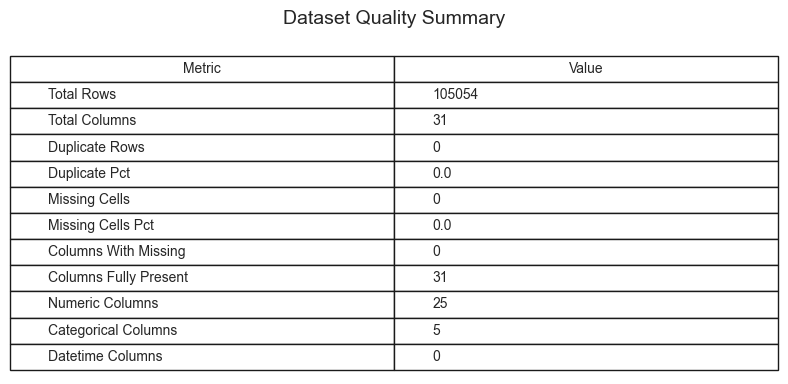

{'total_rows': 105054,
 'total_columns': 31,
 'duplicate_rows': 0,
 'duplicate_pct': 0.0,
 'missing_cells': 0,
 'missing_cells_pct': 0.0,
 'columns_with_missing': 0,
 'columns_fully_present': 31,
 'numeric_columns': 25,
 'categorical_columns': 5,
 'datetime_columns': 0}

In [7]:
# Comprehensive quality snapshot
quality_summary = {
    "total_rows": df.shape[0],
    "total_columns": df.shape[1],
    "duplicate_rows": int(df.duplicated().sum()),
    "duplicate_pct": round(float(df.duplicated().sum() / len(df) * 100), 4),
    "missing_cells": int(df.isna().sum().sum()),
    "missing_cells_pct": round(float(df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100), 4),
    "columns_with_missing": len(missing_stats),
    "columns_fully_present": df.shape[1] - len(missing_stats),
    "numeric_columns": len(df.select_dtypes(include=[np.number]).columns),
    "categorical_columns": len(df.select_dtypes(include=["object", "category"]).columns),
    "datetime_columns": len(df.select_dtypes(include=["datetime64"]).columns),
}
all_stats["quality_summary"] = quality_summary

# Visual quality summary as a table-style plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")
table_data = [[k.replace("_", " ").title(), str(v)] for k, v in quality_summary.items()]
table = ax.table(cellText=table_data, colLabels=["Metric", "Value"], loc="center", cellLoc="left")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
ax.set_title("Dataset Quality Summary", fontsize=14, pad=20)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "quality_summary.png", dpi=110, bbox_inches="tight")
plt.show()

quality_summary

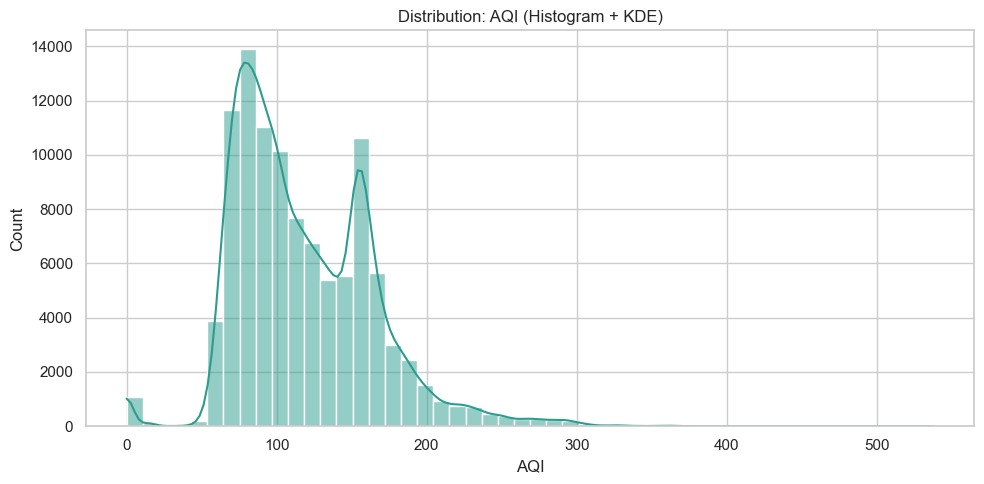

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df[TARGET_COL].dropna(), kde=True, ax=ax, color="#2a9d8f", bins=50)
ax.set_title(f"Distribution: {TARGET_COL.upper()} (Histogram + KDE)")
ax.set_xlabel(TARGET_COL.upper())
ax.set_ylabel("Count")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "aqi_histogram_kde.png", dpi=110, bbox_inches="tight")
plt.show()

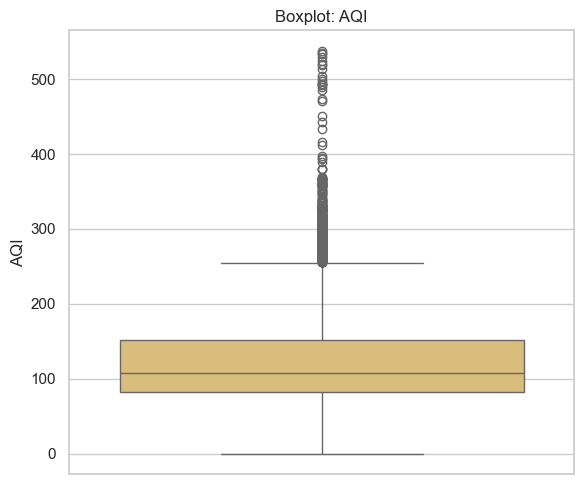

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(y=df[TARGET_COL].dropna(), ax=ax, color="#e9c46a")
ax.set_title(f"Boxplot: {TARGET_COL.upper()}")
ax.set_ylabel(TARGET_COL.upper())
fig.tight_layout()
fig.savefig(FIGURES_DIR / "aqi_boxplot.png", dpi=110, bbox_inches="tight")
plt.show()

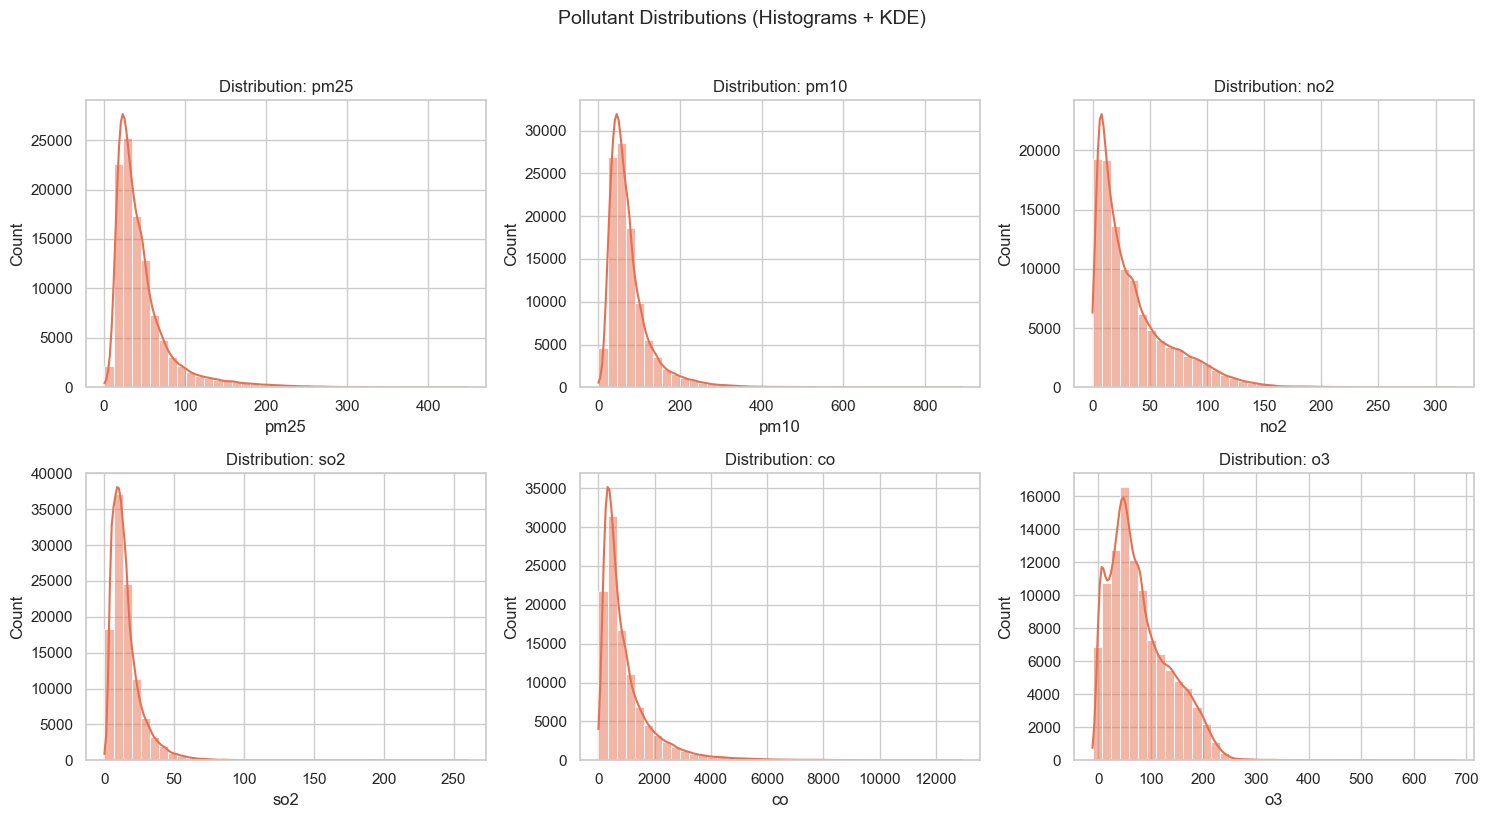

In [10]:
available_pollutants = [c for c in POLLUTANT_COLS if c in df.columns]
ncols = 3
nrows = (len(available_pollutants) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
for i, col in enumerate(available_pollutants):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="#e76f51", bins=40)
    axes[i].set_title(f"Distribution: {col}")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
fig.suptitle("Pollutant Distributions (Histograms + KDE)", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "pollutant_histograms.png", dpi=110, bbox_inches="tight")
plt.show()

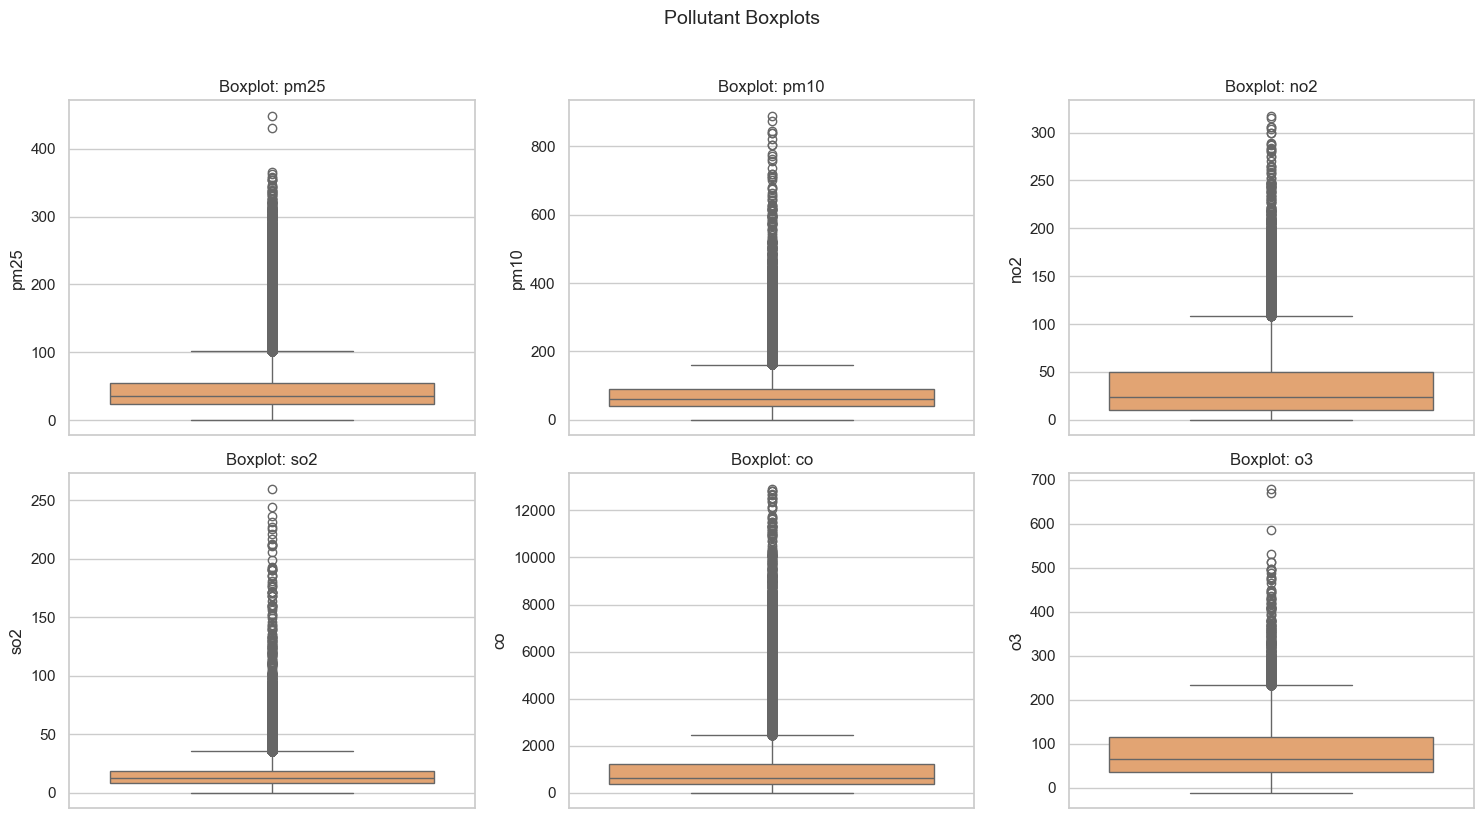

In [11]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
for i, col in enumerate(available_pollutants):
    sns.boxplot(y=df[col].dropna(), ax=axes[i], color="#f4a261")
    axes[i].set_title(f"Boxplot: {col}")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
fig.suptitle("Pollutant Boxplots", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "pollutant_boxplots.png", dpi=110, bbox_inches="tight")
plt.show()

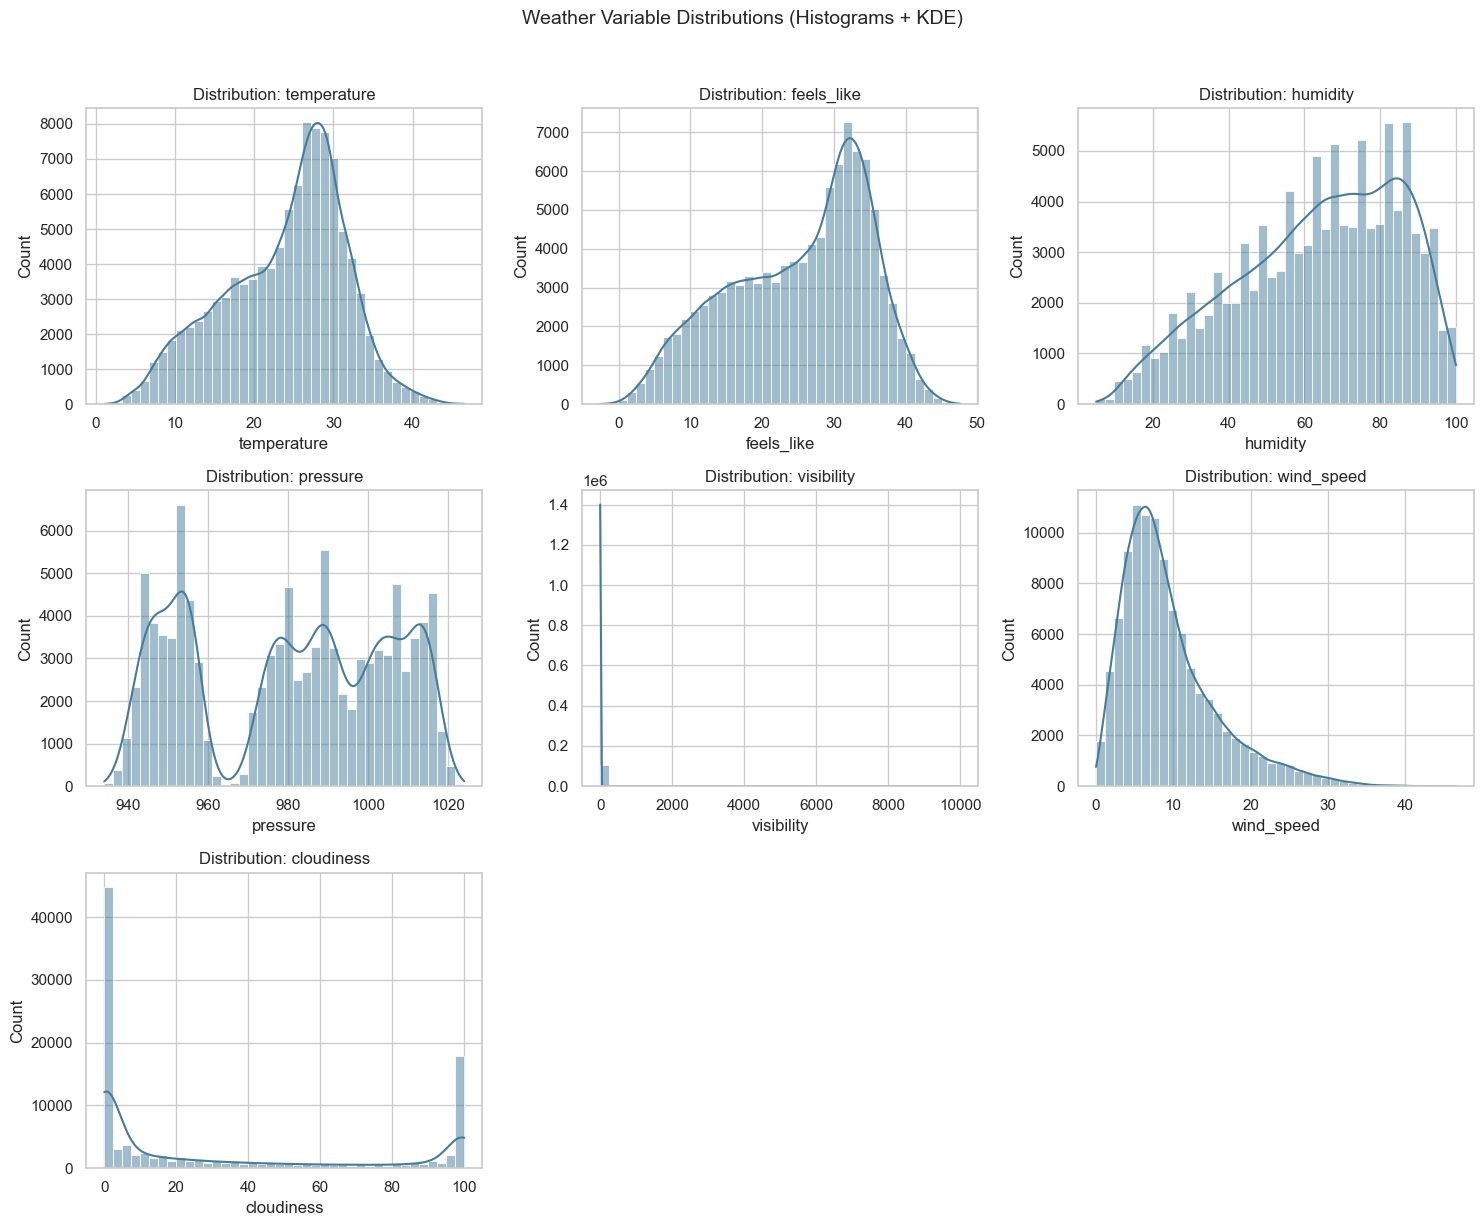

In [12]:
available_weather = [c for c in WEATHER_COLS if c in df.columns]
ncols = 3
nrows = (len(available_weather) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
for i, col in enumerate(available_weather):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="#457b9d", bins=40)
    axes[i].set_title(f"Distribution: {col}")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
fig.suptitle("Weather Variable Distributions (Histograms + KDE)", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "weather_histograms.png", dpi=110, bbox_inches="tight")
plt.show()

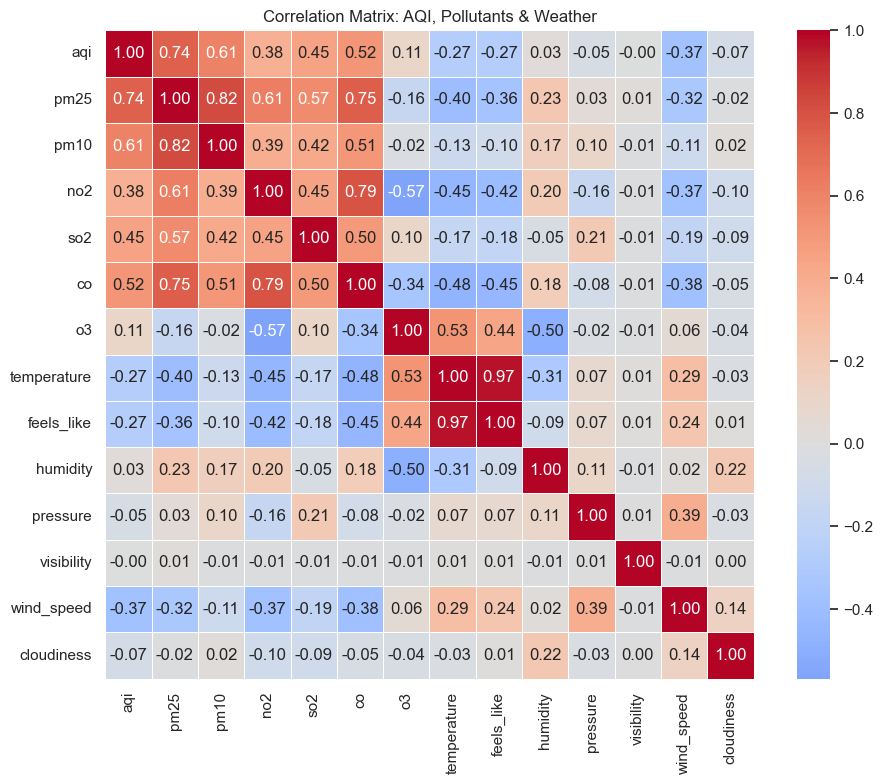

In [13]:
numeric_cols = [c for c in [TARGET_COL] + POLLUTANT_COLS + WEATHER_COLS if c in df.columns]
corr = df[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title("Correlation Matrix: AQI, Pollutants & Weather")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()

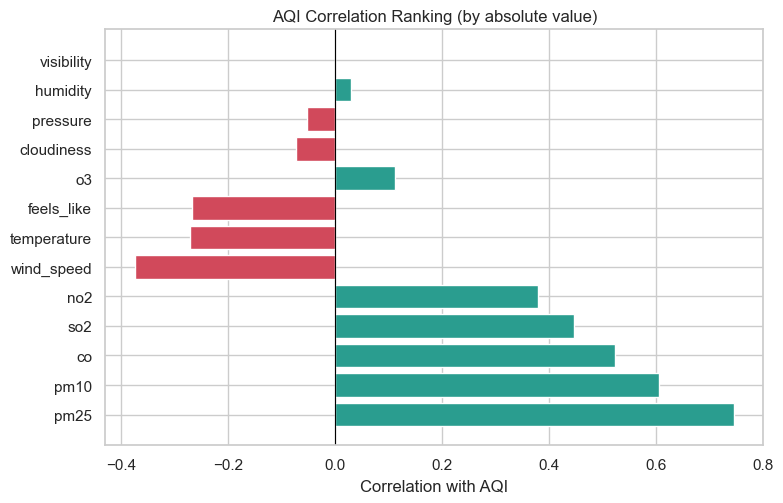

pm25           0.744284
pm10           0.605626
co             0.521938
so2            0.445458
no2            0.378940
wind_speed    -0.373558
temperature   -0.272129
feels_like    -0.268134
o3             0.111189
cloudiness    -0.072908
pressure      -0.052273
humidity       0.030099
visibility    -0.000317
Name: aqi, dtype: float64

In [14]:
aqi_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
all_stats["aqi_correlations"] = {col: round(float(val), 4) for col, val in aqi_corr.items()}

fig, ax = plt.subplots(figsize=(8, max(4, len(aqi_corr) * 0.4)))
colors = ["#2a9d8f" if v > 0 else "#d1495b" for v in aqi_corr.values]
ax.barh(aqi_corr.index, aqi_corr.values, color=colors)
ax.set_xlabel("Correlation with AQI")
ax.set_title("AQI Correlation Ranking (by absolute value)")
ax.axvline(x=0, color="black", linewidth=0.8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "aqi_correlation_ranking.png", dpi=110, bbox_inches="tight")
plt.show()

aqi_corr

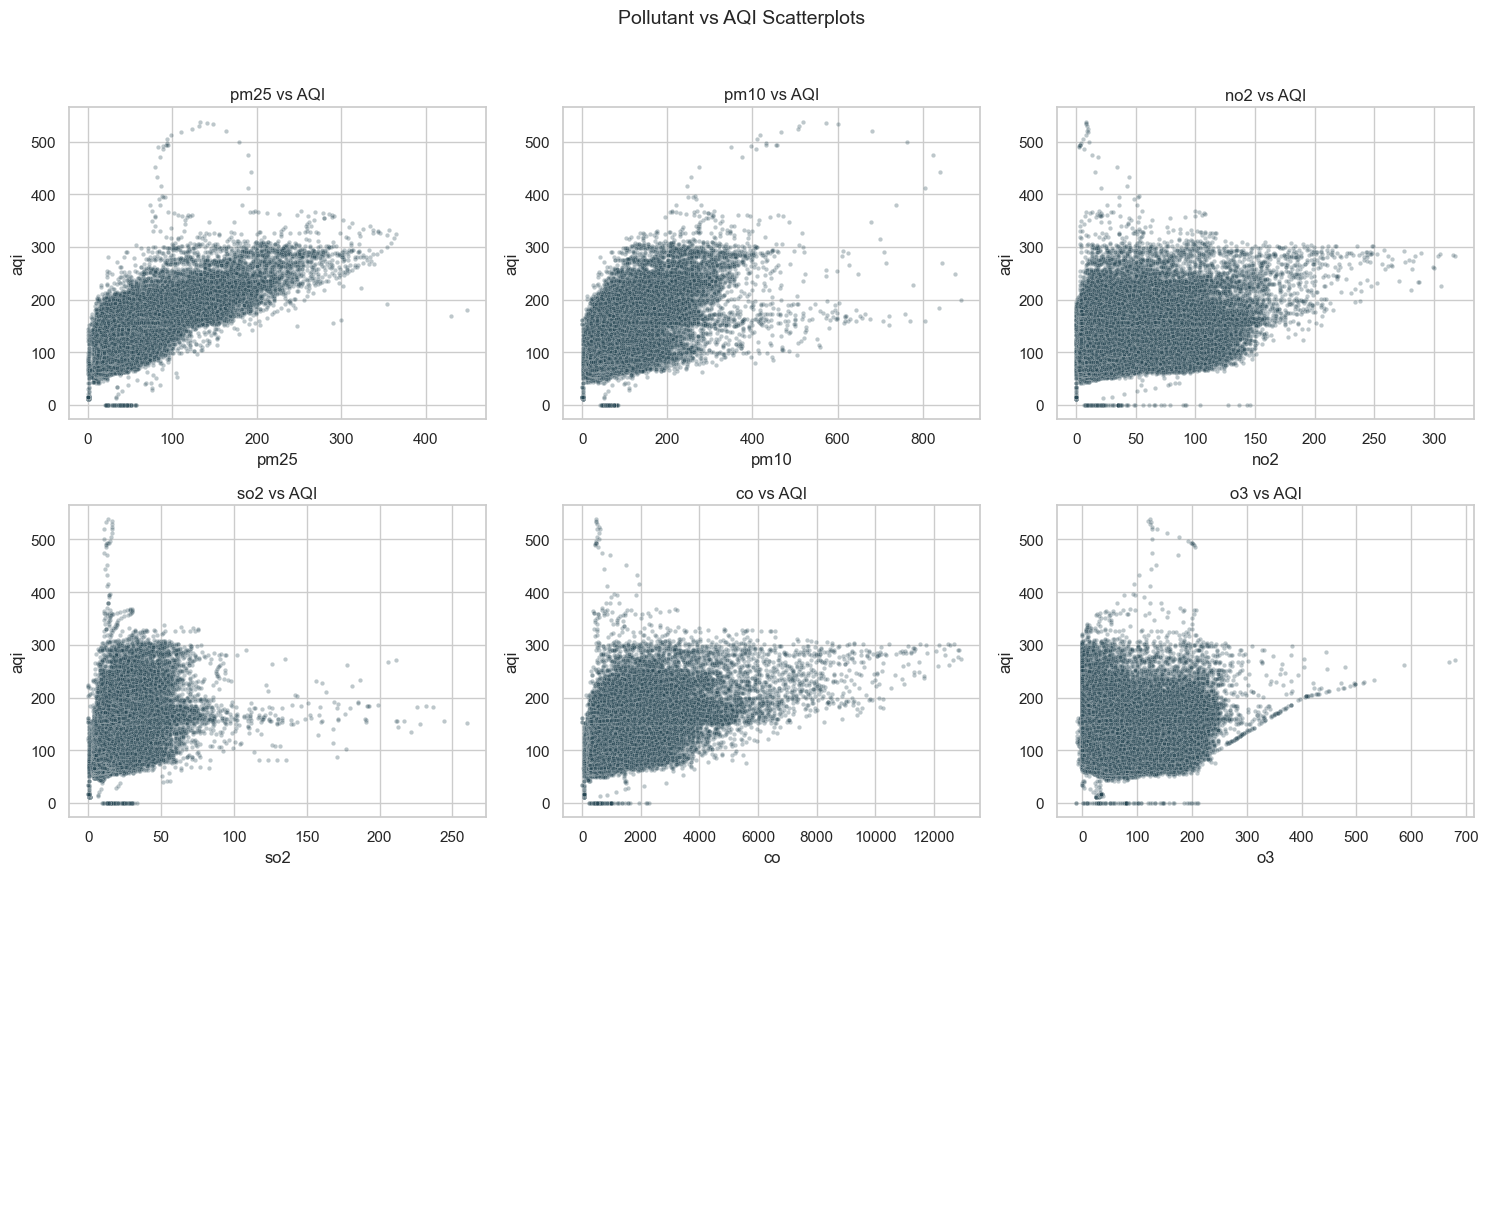

In [15]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
for i, col in enumerate(available_pollutants):
    sns.scatterplot(data=df, x=col, y=TARGET_COL, ax=axes[i], alpha=0.3, color="#264653", s=10)
    axes[i].set_title(f"{col} vs {TARGET_COL.upper()}")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
fig.suptitle("Pollutant vs AQI Scatterplots", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "pollutant_vs_aqi_scatter.png", dpi=110, bbox_inches="tight")
plt.show()

D:\Temp\ipykernel_8280\580599110.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=CITY_COL, y=TARGET_COL, order=order, ax=ax, palette="viridis")


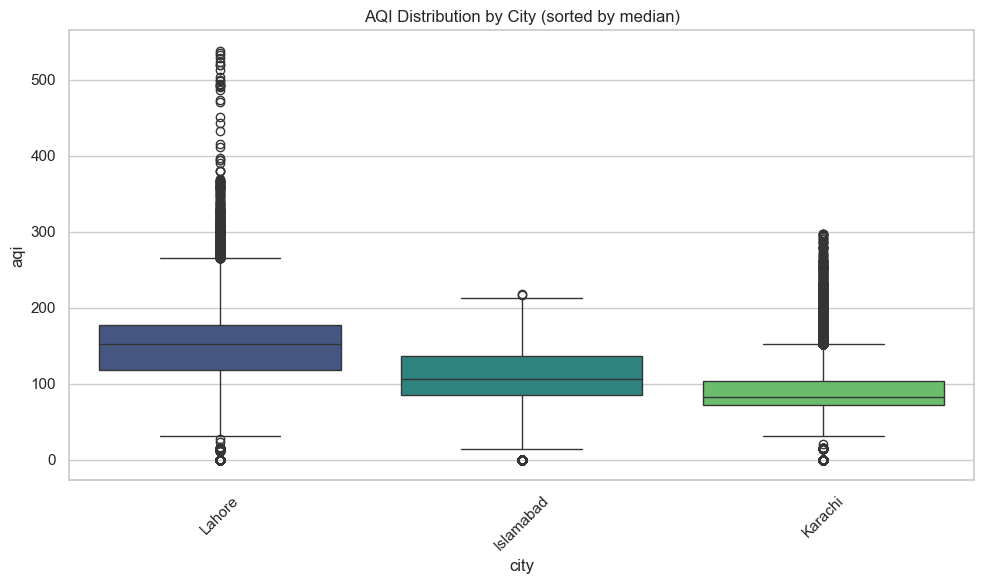

In [16]:
order = df.groupby(CITY_COL)[TARGET_COL].median().sort_values(ascending=False).index
n_cities = df[CITY_COL].nunique()

fig, ax = plt.subplots(figsize=(max(10, n_cities * 1.2), 6))
sns.boxplot(data=df, x=CITY_COL, y=TARGET_COL, order=order, ax=ax, palette="viridis")
ax.set_title("AQI Distribution by City (sorted by median)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "city_aqi_boxplot.png", dpi=110, bbox_inches="tight")
plt.show()

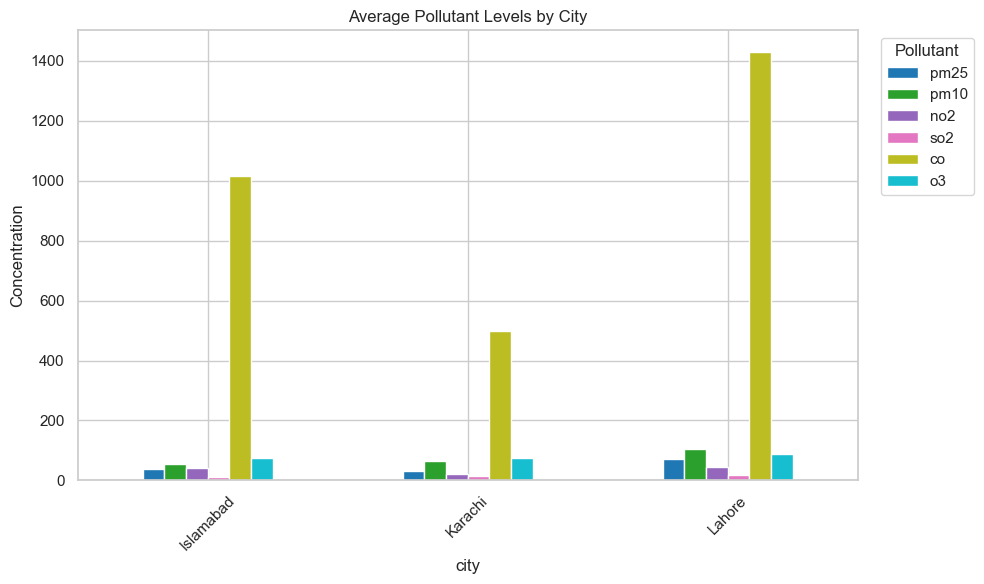

,pm25,pm10,no2,so2,co,o3
city,,,,,,
Islamabad,38.262091,55.611364,41.728552,12.563196,1015.940945,74.690818
Karachi,30.650380,63.174457,21.215108,15.967423,497.829574,74.764723
Lahore,70.290154,105.186856,43.154699,17.875356,1429.889400,87.773689


In [17]:
city_pollutant_avg = df.groupby(CITY_COL)[available_pollutants].mean()
all_stats["avg_pollutants_by_city"] = city_pollutant_avg.round(2).to_dict(orient="index")

fig, ax = plt.subplots(figsize=(max(10, n_cities * 1.3), 6))
city_pollutant_avg.plot(kind="bar", ax=ax, colormap="tab10")
ax.set_title("Average Pollutant Levels by City")
ax.set_ylabel("Concentration")
ax.legend(title="Pollutant", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "city_pollutant_avg.png", dpi=110, bbox_inches="tight")
plt.show()

city_pollutant_avg

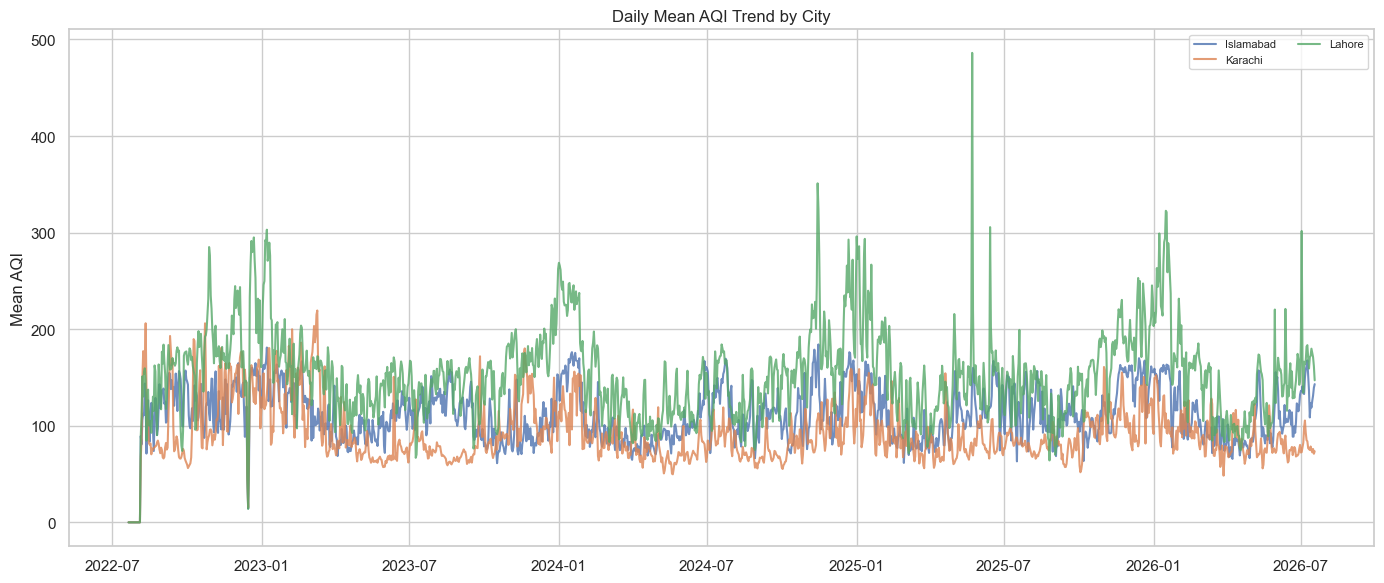

,mean,median,std,min,max,count
city,,,,,,
Islamabad,110.97,106.0,33.09,0,218,35018
Karachi,91.78,83.0,32.03,0,297,35018
Lahore,152.13,153.0,50.04,0,538,35018


In [18]:
city_summary = (
    df.groupby(CITY_COL)[TARGET_COL]
    .agg(["mean", "median", "std", "min", "max", "count"])
    .round(2)
)
all_stats["per_city_stats"] = city_summary.to_dict(orient="index")

fig, ax = plt.subplots(figsize=(14, 6))
for city, group in df.groupby(CITY_COL):
    daily = group.set_index(TIME_COL)[TARGET_COL].resample("1D").mean()
    ax.plot(daily.index, daily.values, label=city, alpha=0.8)
ax.set_title("Daily Mean AQI Trend by City")
ax.set_ylabel("Mean AQI")
ax.legend(loc="upper right", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "city_trends.png", dpi=110, bbox_inches="tight")
plt.show()

city_summary

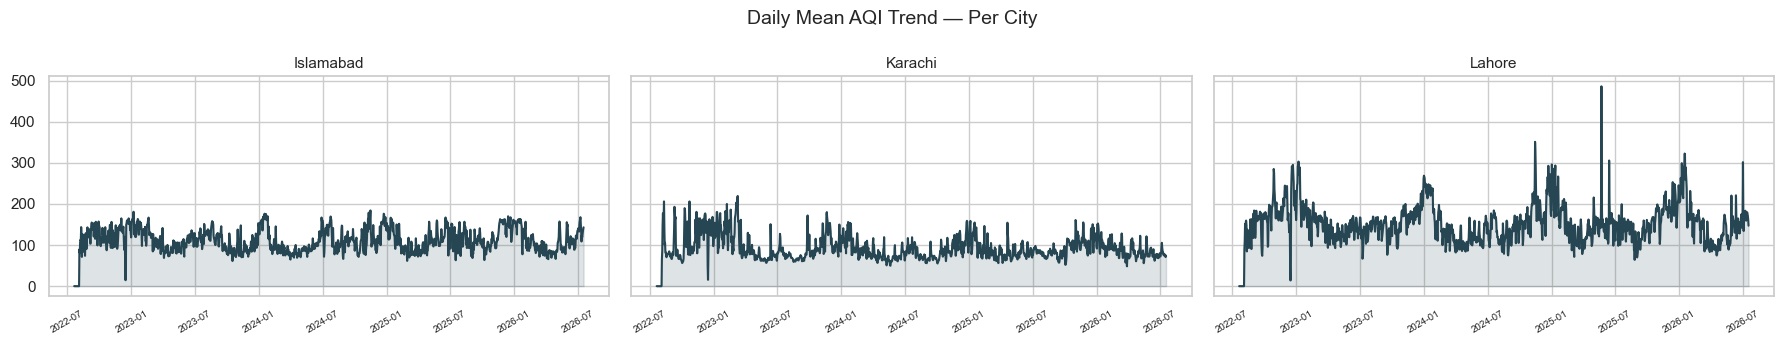

In [19]:
cities = sorted(df[CITY_COL].dropna().unique())
n_cities = len(cities)
ncols = 3
nrows = (n_cities + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows), sharey=True)
axes = axes.flatten()
for i, city in enumerate(cities):
    group = df[df[CITY_COL] == city]
    daily = group.set_index(TIME_COL)[TARGET_COL].resample("1D").mean()
    axes[i].plot(daily.index, daily.values, color="#264653")
    axes[i].fill_between(daily.index, daily.values, alpha=0.15, color="#264653")
    axes[i].set_title(city, fontsize=11)
    axes[i].tick_params(axis="x", rotation=30, labelsize=7)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
fig.suptitle("Daily Mean AQI Trend — Per City", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "city_trend_grid.png", dpi=110, bbox_inches="tight")
plt.show()

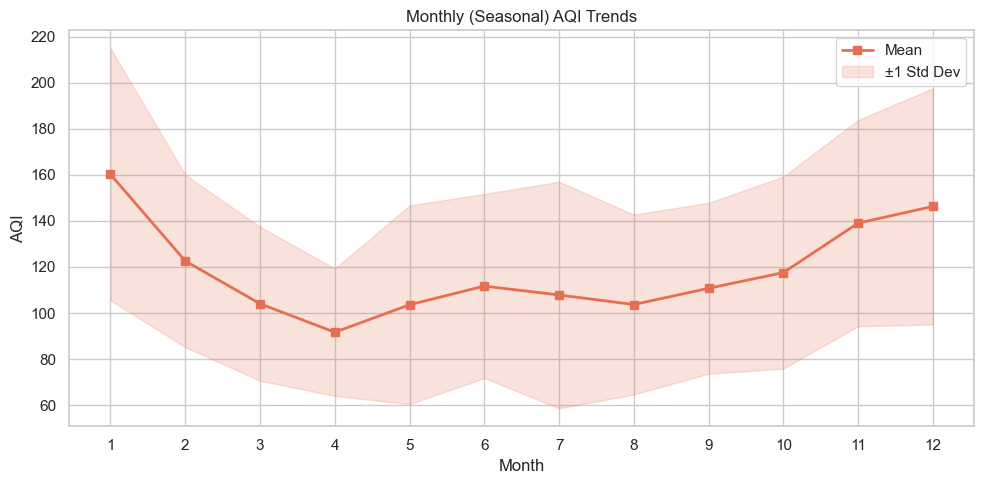

,mean,median,std
month,,,
1,160.23,153.0,54.73
2,122.61,116.0,37.45
3,104.04,95.0,33.43
4,91.66,84.0,27.68
5,103.59,91.0,43.14
6,111.71,100.0,40.01
7,107.84,104.0,49.21
8,103.69,98.0,39.07
9,110.75,104.0,37.10


In [20]:
# Derive month if not present
df["month"] = df[TIME_COL].dt.month

monthly = df.groupby("month")[TARGET_COL].agg(["mean", "median", "std"]).round(2)
all_stats["monthly_aqi_trends"] = monthly.to_dict(orient="index")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly.index, monthly["mean"], marker="s", color="#e76f51", label="Mean", linewidth=2)
ax.fill_between(monthly.index, monthly["mean"] - monthly["std"], monthly["mean"] + monthly["std"],
                alpha=0.2, color="#e76f51", label="±1 Std Dev")
ax.set_title("Monthly (Seasonal) AQI Trends")
ax.set_xlabel("Month")
ax.set_ylabel("AQI")
ax.set_xticks(range(1, 13))
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "monthly_aqi_trends.png", dpi=110, bbox_inches="tight")
plt.show()

monthly

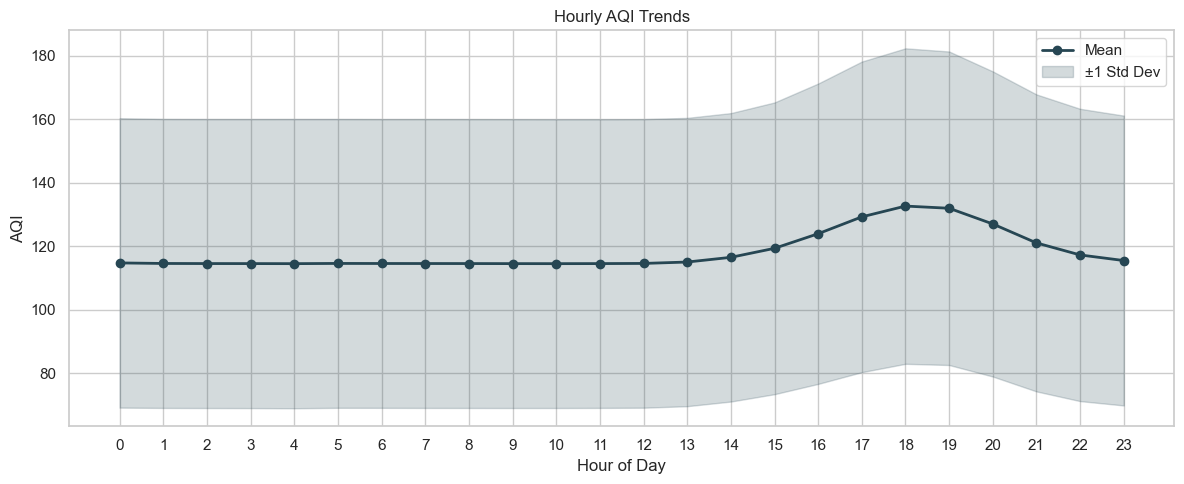

,mean,median,std
hour,,,
0,114.75,103.0,45.58
1,114.58,103.0,45.51
2,114.55,103.0,45.51
3,114.54,103.0,45.52
4,114.52,103.0,45.55
5,114.59,103.0,45.48
6,114.57,103.0,45.47
7,114.56,103.0,45.49
8,114.55,103.0,45.49


In [21]:
# Derive hour if not present
df["hour"] = df[TIME_COL].dt.hour

hourly = df.groupby("hour")[TARGET_COL].agg(["mean", "median", "std"]).round(2)
all_stats["hourly_aqi_trends"] = hourly.to_dict(orient="index")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly.index, hourly["mean"], marker="o", color="#264653", label="Mean", linewidth=2)
ax.fill_between(hourly.index, hourly["mean"] - hourly["std"], hourly["mean"] + hourly["std"],
                alpha=0.2, color="#264653", label="±1 Std Dev")
ax.set_title("Hourly AQI Trends")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("AQI")
ax.set_xticks(range(0, 24))
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "hourly_aqi_trends.png", dpi=110, bbox_inches="tight")
plt.show()

hourly

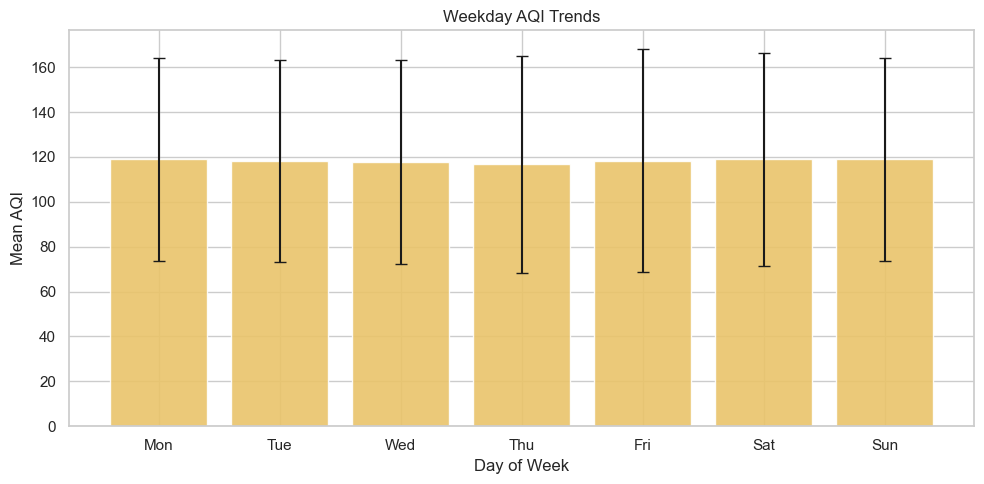

,mean,median,std
day_of_week,,,
0,118.92,108.0,45.17
1,118.33,109.0,45.05
2,117.81,108.0,45.43
3,116.67,106.0,48.28
4,118.36,107.0,49.64
5,118.98,109.0,47.45
6,118.96,111.0,45.20


In [22]:
# Derive day_of_week if not present (0=Monday)
df["day_of_week"] = df[TIME_COL].dt.dayofweek

dow = df.groupby("day_of_week")[TARGET_COL].agg(["mean", "median", "std"]).round(2)
all_stats["weekday_aqi_trends"] = dow.to_dict(orient="index")

fig, ax = plt.subplots(figsize=(10, 5))
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
ax.bar(range(7), dow["mean"], color="#e9c46a", yerr=dow["std"], capsize=4, alpha=0.9)
ax.set_title("Weekday AQI Trends")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Mean AQI")
ax.set_xticks(range(7))
ax.set_xticklabels(day_labels)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "weekday_aqi_trends.png", dpi=110, bbox_inches="tight")
plt.show()

dow

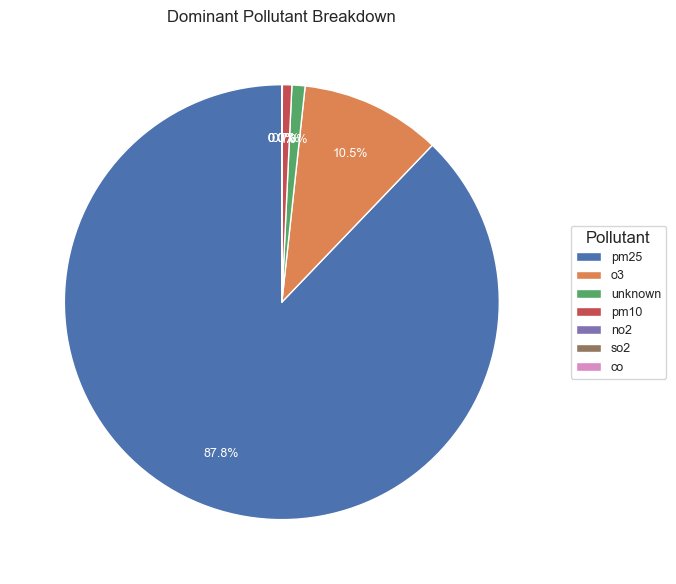

dominant_pollutant
pm25       92275
o3         10980
unknown     1023
pm10         735
no2           24
so2           15
co             2
Name: count, dtype: int64


In [23]:
if "dominant_pollutant" in df.columns:
    counts = df["dominant_pollutant"].value_counts()
    all_stats["dominant_pollutant_counts"] = counts.to_dict()

    fig, ax = plt.subplots(figsize=(8, 6))
    wedges, _, autotexts = ax.pie(
        counts.values,
        labels=None,
        autopct="%1.1f%%",
        pctdistance=0.75,
        startangle=90,
        wedgeprops={"linewidth": 1, "edgecolor": "white"},
    )
    for t in autotexts:
        t.set_fontsize(9)
        t.set_color("white")

    ax.legend(
        wedges,
        counts.index,
        title="Pollutant",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9,
    )
    ax.set_title("Dominant Pollutant Breakdown")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "dominant_pollutant.png", dpi=110, bbox_inches="tight")
    plt.show()
    print(counts)
else:
    print("Column 'dominant_pollutant' not found in dataset.")

In [26]:
with STATS_PATH.open("w", encoding="utf-8") as f:
    json.dump(
        {
            "generated_at": datetime.now(timezone.utc).isoformat(),
            "dataset_path": str(DATA_PATH),
            "shape": {"rows": df.shape[0], "columns": df.shape[1]},
            **all_stats,
        },
        f,
        indent=2,
        default=str,
    )

print(f"Stats saved -> {STATS_PATH}")

Stats saved -> ..\reports\eda\eda_stats.json
